# A/B TESTING

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from statsmodels.stats.proportion import proportions_ztest

## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
folder_path = "/content/drive/MyDrive/data1/ab_testing"

os.listdir(folder_path)

['Model_B_B4.csv',
 'Model_A_B4.csv',
 'hasil_ab_testing.csv',
 'hasil_ab_testing_lengkap.csv',
 'hasil_perbandingan_per_label.csv']

## Load Dataset Model A dan Model B

In [4]:
df_a = pd.read_csv("/content/drive/MyDrive/data1/ab_testing/Model_A_B4.csv")
df_b = pd.read_csv("/content/drive/MyDrive/data1/ab_testing/Model_B_B4.csv")

print("Shape Model A:", df_a.shape)
print("Shape Model B:", df_b.shape)

Shape Model A: (42389, 6)
Shape Model B: (42389, 7)


## Pemeriksaan Kolom


In [5]:
print("Kolom Model A:")
print(df_a.columns)

print("\nKolom Model B:")
print(df_b.columns)

Kolom Model A:
Index(['job_title', 'job_type', 'salary', 'job_skill', 'gaji_perbulan',
       'final_category'],
      dtype='object')

Kolom Model B:
Index(['job_title', 'job_type', 'salary', 'job_skill', 'gaji_perbulan',
       'clean_text', 'label'],
      dtype='object')


## Preview Data

In [6]:
df_a.head()

,job_title,job_type,salary,job_skill,gaji_perbulan,final_category
0,Procurement Executive Contract,Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562",general_role
1,Account Executive/ Assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",Communication,"4,167 - 6,250",finance_accounting
2,Data Analyst - Asset Management Spx Express,Full-time,"USD 60,000 - 90,000 / YEARLY",Data Analysis,"5,000 - 7,500",data_analyst_bi
3,Service Engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",React,"5,833 - 8,750",frontend_dev
4,Purchasing Executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875",general_role


In [7]:
df_b.head()

,job_title,job_type,salary,job_skill,gaji_perbulan,clean_text,label
0,procurement executive contract,Contract,"USD 45,000 - 90,750 / YEARLY",communication,"3,750 - 7,562",procurement executive contract communication,procurement
1,account executive/ assistant,Full-time,"USD 50,000 - 75,000 / YEARLY",communication,"4,167 - 6,250",account executive/ assistant communication,sales
2,data analyst - asset management spx express,Full-time,"USD 60,000 - 90,000 / YEARLY",data analysis,"5,000 - 7,500",data analyst - asset management spx express da...,data_analyst_bi
3,service engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",react,"5,833 - 8,750",service engineer react,technical_support
4,purchasing executive,Full-time,"USD 45,000 - 82,500 / YEARLY",communication,"3,750 - 6,875",purchasing executive communication,procurement


## Standarisasi Nama Kolom Target


In [8]:
df_a = df_a.rename(columns={
    "final_category": "category"
})

df_b = df_b.rename(columns={
    "label": "category"
})

In [9]:
print("Kolom Model A setelah rename:")
print(df_a.columns)

print("\nKolom Model B setelah rename:")
print(df_b.columns)

Kolom Model A setelah rename:
Index(['job_title', 'job_type', 'salary', 'job_skill', 'gaji_perbulan',
       'category'],
      dtype='object')

Kolom Model B setelah rename:
Index(['job_title', 'job_type', 'salary', 'job_skill', 'gaji_perbulan',
       'clean_text', 'category'],
      dtype='object')


## Cek Missing Value

In [10]:
print("Missing value Model A:")
print(df_a.isnull().sum())

print("\nMissing value Model B:")
print(df_b.isnull().sum())

Missing value Model A:
job_title        28
job_type          0
salary            0
job_skill         0
gaji_perbulan     0
category          0
dtype: int64

Missing value Model B:
job_title        28
job_type          0
salary            0
job_skill         0
gaji_perbulan     0
clean_text        0
category          0
dtype: int64


## Cek Duplikasi Data

In [11]:
print("Jumlah duplikat Model A:", df_a.duplicated().sum())
print("Jumlah duplikat Model B:", df_b.duplicated().sum())

Jumlah duplikat Model A: 768
Jumlah duplikat Model B: 768


## Cleaning Data A/B Testing

In [12]:
# Bersihkan missing value pada job_title
df_a = df_a.dropna(subset=["job_title"]).copy()
df_b = df_b.dropna(subset=["job_title"]).copy()

# Hapus duplikasi
df_a = df_a.drop_duplicates().copy()
df_b = df_b.drop_duplicates().copy()

print("Shape Model A setelah cleaning:", df_a.shape)
print("Shape Model B setelah cleaning:", df_b.shape)

print("\nMissing value Model A:")
print(df_a.isnull().sum())

print("\nMissing value Model B:")
print(df_b.isnull().sum())

print("\nJumlah duplikat Model A:", df_a.duplicated().sum())
print("Jumlah duplikat Model B:", df_b.duplicated().sum())

Shape Model A setelah cleaning: (41618, 6)
Shape Model B setelah cleaning: (41618, 7)

Missing value Model A:
job_title        0
job_type         0
salary           0
job_skill        0
gaji_perbulan    0
category         0
dtype: int64

Missing value Model B:
job_title        0
job_type         0
salary           0
job_skill        0
gaji_perbulan    0
clean_text       0
category         0
dtype: int64

Jumlah duplikat Model A: 0
Jumlah duplikat Model B: 0


## Distribusi Kategori Model A dan Model B

In [13]:
category_a = df_a["category"].value_counts()
category_b = df_b["category"].value_counts()

print("Distribusi kategori Model A:")
print(category_a)

print("\nDistribusi kategori Model B:")
print(category_b)

Distribusi kategori Model A:
category
data_analyst_bi       10134
general_role           7881
finance_accounting     3807
sales                  3085
admin                  2739
data_science_ai        2334
general_engineer       2267
management             1613
digital_marketing      1505
customer_service       1471
backend_dev            1032
hr_recruitment          999
software_dev            952
network_security        569
internship              462
frontend_dev            355
general_analyst         337
mobile_dev               54
cloud_devops             22
Name: count, dtype: int64

Distribusi kategori Model B:
category
administration        13413
sales                  4325
finance_accounting     3501
technical_support      3342
management             3294
hr_recruitment         2067
customer_service       1989
internship             1659
software_dev           1470
procurement            1460
digital_marketing      1285
data_analyst_bi        1231
backend_dev             849
n

## Jumlah Kategori

In [14]:
print("Jumlah kategori Model A:", df_a["category"].nunique())
print("Jumlah kategori Model B:", df_b["category"].nunique())

Jumlah kategori Model A: 19
Jumlah kategori Model B: 19


## Cek Label General atau Other

In [15]:
general_keywords = ["general", "other"]

general_a = df_a[
    df_a["category"].astype(str).str.contains(
        "|".join(general_keywords),
        case=False,
        na=False
    )
]

general_b = df_b[
    df_b["category"].astype(str).str.contains(
        "|".join(general_keywords),
        case=False,
        na=False
    )
]

jumlah_general_a = len(general_a)
jumlah_general_b = len(general_b)

persen_general_a = jumlah_general_a / len(df_a) * 100
persen_general_b = jumlah_general_b / len(df_b) * 100

print("Jumlah label general/other di Model A:", jumlah_general_a)
print("Jumlah label general/other di Model B:", jumlah_general_b)

print("\nPersentase label general/other Model A:", round(persen_general_a, 2), "%")
print("Persentase label general/other Model B:", round(persen_general_b, 2), "%")

Jumlah label general/other di Model A: 10485
Jumlah label general/other di Model B: 0

Persentase label general/other Model A: 25.19 %
Persentase label general/other Model B: 0.0 %


## Contoh Data dengan Label General atau Other

In [16]:
if len(general_a) > 0:
    display(general_a.head(20))
else:
    print("Model A tidak memiliki label general/other.")

,job_title,job_type,salary,job_skill,gaji_perbulan,category
0,Procurement Executive Contract,Contract,"USD 45,000 - 90,750 / YEARLY",Communication,"3,750 - 7,562",general_role
4,Purchasing Executive,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875",general_role
9,Clerical Assistant Educational Centre,Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167",general_role
11,Purchasing Assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167",general_role
14,Audit Assistant,Full-time,"USD 70,000 - 105,000 / YEARLY",Communication,"5,833 - 8,750",general_role
19,Invoicing Assistant,Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167",general_role
22,Audit Associate,Full-time,"USD 70,000 - 105,000 / YEARLY",Communication,"5,833 - 8,750",general_role
24,Mechanical Design Engineer,Full-time,"USD 70,000 - 105,000 / YEARLY",Communication,"5,833 - 8,750",general_engineer
37,Planner Controller,Full-time,"USD 45,000 - 82,500 / YEARLY",Communication,"3,750 - 6,875",general_role
42,Operation Clerk,Full-time,"USD 30,000 - 50,000 / YEARLY",Communication,"2,500 - 4,167",general_role


In [17]:
if len(general_b) > 0:
    display(general_b.head(20))
else:
    print("Model B tidak memiliki label general/other.")

Model B tidak memiliki label general/other.


## Tabel Perbandingan A/B Testing

In [18]:
comparison_ab = pd.DataFrame({
    "Aspek": [
        "Jumlah Data",
        "Jumlah Kategori",
        "Jumlah Label General/Other",
        "Persentase Label General/Other",
        "Missing Value Total",
        "Jumlah Duplikat",
        "Job Title Unik",
        "Skill Kosong"
    ],
    "Model A": [
        len(df_a),
        df_a["category"].nunique(),
        jumlah_general_a,
        round(persen_general_a, 2),
        df_a.isnull().sum().sum(),
        df_a.duplicated().sum(),
        df_a["job_title"].nunique() if "job_title" in df_a.columns else np.nan,
        (df_a["job_skill"].astype(str).str.strip() == "").sum() if "job_skill" in df_a.columns else np.nan
    ],
    "Model B": [
        len(df_b),
        df_b["category"].nunique(),
        jumlah_general_b,
        round(persen_general_b, 2),
        df_b.isnull().sum().sum(),
        df_b.duplicated().sum(),
        df_b["job_title"].nunique() if "job_title" in df_b.columns else np.nan,
        (df_b["job_skill"].astype(str).str.strip() == "").sum() if "job_skill" in df_b.columns else np.nan
    ]
})

comparison_ab

,Aspek,Model A,Model B
0,Jumlah Data,41618.00,41618.0
1,Jumlah Kategori,19.00,19.0
2,Jumlah Label General/Other,10485.00,0.0
3,Persentase Label General/Other,25.19,0.0
4,Missing Value Total,0.00,0.0
5,Jumlah Duplikat,0.00,0.0
6,Job Title Unik,37765.00,37765.0
7,Skill Kosong,0.00,0.0


## Uji Z-Test Proporsi Label General atau Other

In [19]:
count = np.array([jumlah_general_a, jumlah_general_b])
nobs = np.array([len(df_a), len(df_b)])

z_statistic, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

print("Hasil Uji Z-Test Proporsi General/Other")
print("Z-statistic:", round(z_statistic, 4))
print("P-value:", round(p_value, 4))

Hasil Uji Z-Test Proporsi General/Other
Z-statistic: 109.5268
P-value: 0.0


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Terdapat perbedaan signifikan antara proporsi label general/other pada Model A dan Model B.")
else:
    print("Tidak terdapat perbedaan signifikan antara proporsi label general/other pada Model A dan Model B.")

Terdapat perbedaan signifikan antara proporsi label general/other pada Model A dan Model B.


## Persentase Label General atau Other

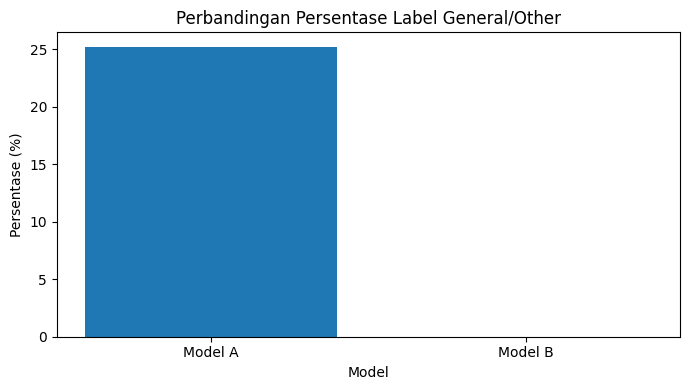

In [21]:
plt.figure(figsize=(7,4))

plt.bar(
    ["Model A", "Model B"],
    [persen_general_a, persen_general_b]
)

plt.title("Perbandingan Persentase Label General/Other")
plt.xlabel("Model")
plt.ylabel("Persentase (%)")
plt.tight_layout()
plt.show()

## Visualisasi Distribusi Kategori Model A

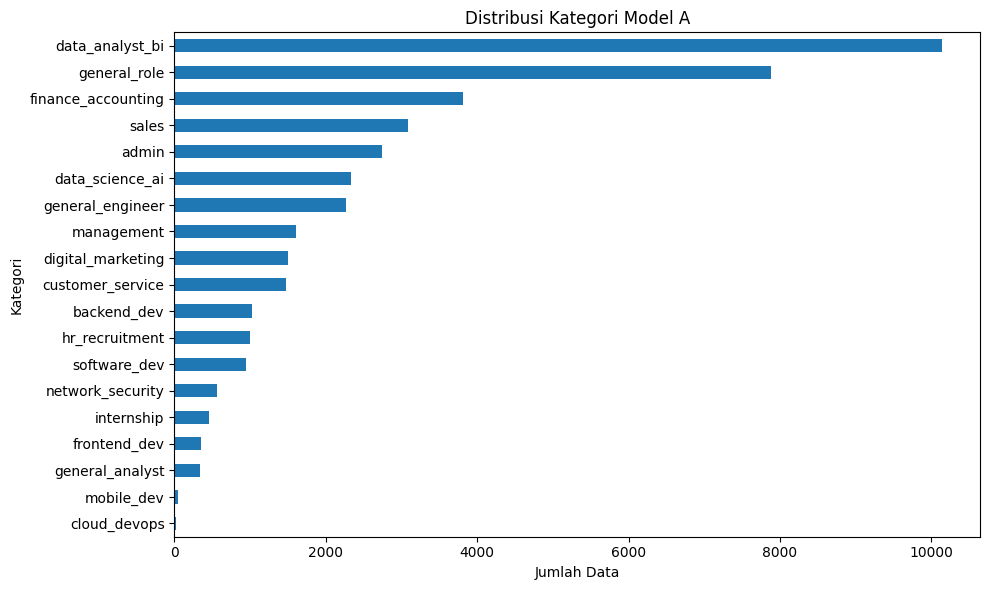

In [22]:
plt.figure(figsize=(10,6))
category_a.sort_values(ascending=True).plot(kind="barh")
plt.title("Distribusi Kategori Model A")
plt.xlabel("Jumlah Data")
plt.ylabel("Kategori")
plt.tight_layout()
plt.show()

## Visualisasi Distribusi Kategori Model B

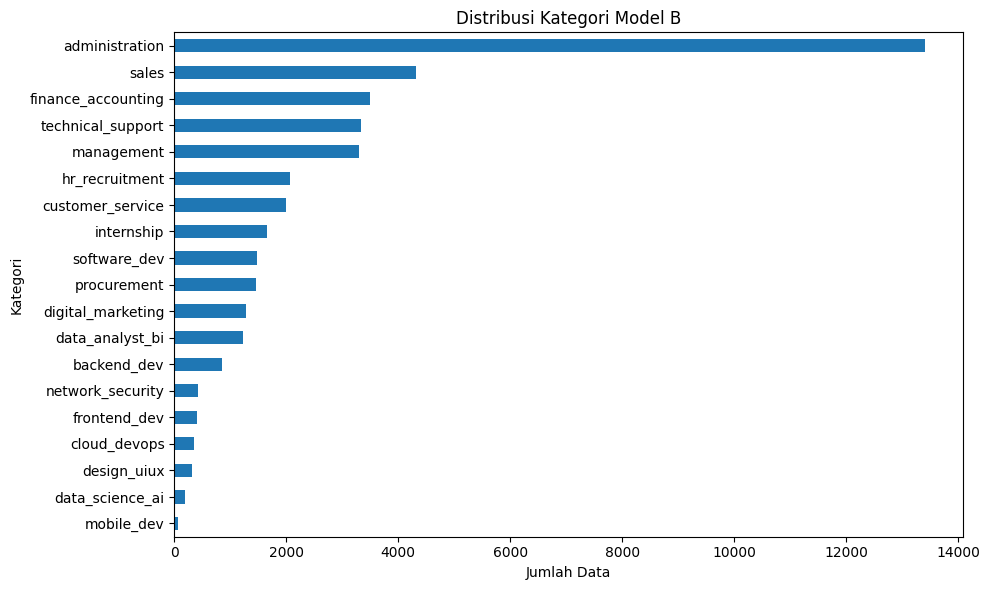

In [23]:
plt.figure(figsize=(10,6))
category_b.sort_values(ascending=True).plot(kind="barh")
plt.title("Distribusi Kategori Model B")
plt.xlabel("Jumlah Data")
plt.ylabel("Kategori")
plt.tight_layout()
plt.show()

## Visualisasi Perbandingan Label General atau Other

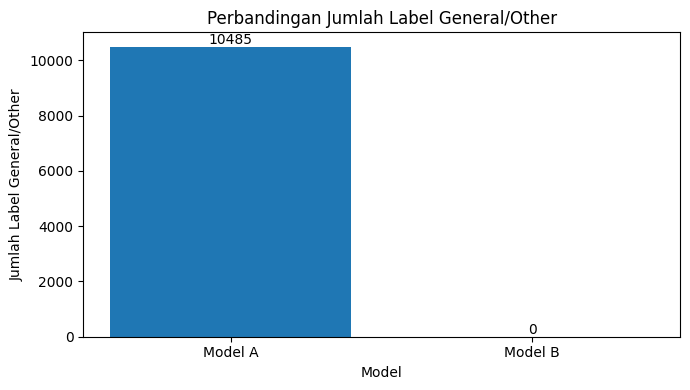

In [24]:
plt.figure(figsize=(7,4))

bars = plt.bar(
    ["Model A", "Model B"],
    [jumlah_general_a, jumlah_general_b]
)

plt.title("Perbandingan Jumlah Label General/Other")
plt.xlabel("Model")
plt.ylabel("Jumlah Label General/Other")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Perbandingan Per Label Model A dan Model B

In [25]:
label_a = df_a["category"].value_counts().reset_index()
label_a.columns = ["category", "count_A"]

label_b = df_b["category"].value_counts().reset_index()
label_b.columns = ["category", "count_B"]

label_comparison = pd.merge(
    label_a,
    label_b,
    on="category",
    how="outer"
).fillna(0)

label_comparison["count_A"] = label_comparison["count_A"].astype(int)
label_comparison["count_B"] = label_comparison["count_B"].astype(int)

label_comparison["selisih_B_minus_A"] = (
    label_comparison["count_B"] - label_comparison["count_A"]
)

label_comparison["persentase_A"] = (
    label_comparison["count_A"] / len(df_a) * 100
).round(2)

label_comparison["persentase_B"] = (
    label_comparison["count_B"] / len(df_b) * 100
).round(2)

label_comparison["selisih_persentase"] = (
    label_comparison["persentase_B"] - label_comparison["persentase_A"]
).round(2)

label_comparison = label_comparison.sort_values(
    by="selisih_B_minus_A",
    ascending=False
)

label_comparison

,category,count_A,count_B,selisih_B_minus_A,persentase_A,persentase_B,selisih_persentase
1,administration,0,13413,13413,0.00,32.23,32.23
22,technical_support,0,3342,3342,0.00,8.03,8.03
16,management,1613,3294,1681,3.88,7.91,4.03
19,procurement,0,1460,1460,0.00,3.51,3.51
20,sales,3085,4325,1240,7.41,10.39,2.98
15,internship,462,1659,1197,1.11,3.99,2.88
14,hr_recruitment,999,2067,1068,2.40,4.97,2.57
21,software_dev,952,1470,518,2.29,3.53,1.24
4,customer_service,1471,1989,518,3.53,4.78,1.25
3,cloud_devops,22,347,325,0.05,0.83,0.78


## Label yang Hanya Ada pada Salah Satu Model

In [26]:
label_only_a = label_comparison[
    (label_comparison["count_A"] > 0) &
    (label_comparison["count_B"] == 0)
]

label_only_b = label_comparison[
    (label_comparison["count_A"] == 0) &
    (label_comparison["count_B"] > 0)
]

print("Label yang hanya ada di Model A:")
display(label_only_a)

print("Label yang hanya ada di Model B:")
display(label_only_b)

Label yang hanya ada di Model A:


,category,count_A,count_B,selisih_B_minus_A,persentase_A,persentase_B,selisih_persentase
11,general_analyst,337,0,-337,0.81,0.0,-0.81
12,general_engineer,2267,0,-2267,5.45,0.0,-5.45
0,admin,2739,0,-2739,6.58,0.0,-6.58
13,general_role,7881,0,-7881,18.94,0.0,-18.94


Label yang hanya ada di Model B:


,category,count_A,count_B,selisih_B_minus_A,persentase_A,persentase_B,selisih_persentase
1,administration,0,13413,13413,0.0,32.23,32.23
22,technical_support,0,3342,3342,0.0,8.03,8.03
19,procurement,0,1460,1460,0.0,3.51,3.51
7,design_uiux,0,308,308,0.0,0.74,0.74


## Visualisasi Perbandingan Per Label

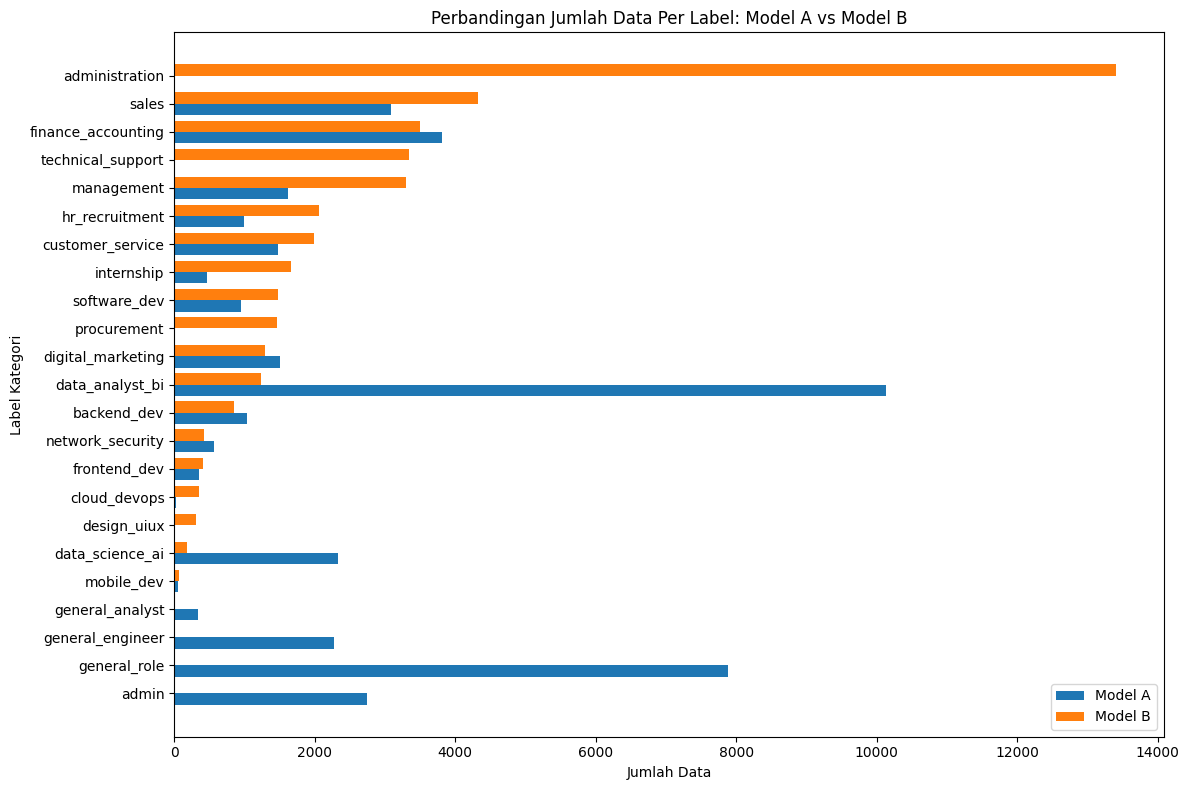

In [27]:
label_comparison_plot = label_comparison.sort_values(
    by="count_B",
    ascending=True
)

plt.figure(figsize=(12,8))

x = np.arange(len(label_comparison_plot["category"]))
width = 0.4

plt.barh(
    x - width/2,
    label_comparison_plot["count_A"],
    height=width,
    label="Model A"
)

plt.barh(
    x + width/2,
    label_comparison_plot["count_B"],
    height=width,
    label="Model B"
)

plt.yticks(
    x,
    label_comparison_plot["category"]
)

plt.title("Perbandingan Jumlah Data Per Label: Model A vs Model B")
plt.xlabel("Jumlah Data")
plt.ylabel("Label Kategori")
plt.legend()
plt.tight_layout()
plt.show()

## Top Label dengan Perubahan Terbesar

In [28]:
label_comparison["abs_selisih"] = label_comparison["selisih_B_minus_A"].abs()

top_changed_labels = label_comparison.sort_values(
    by="abs_selisih",
    ascending=False
).head(10)

top_changed_labels[
    [
        "category",
        "count_A",
        "count_B",
        "selisih_B_minus_A",
        "persentase_A",
        "persentase_B",
        "selisih_persentase"
    ]
]

,category,count_A,count_B,selisih_B_minus_A,persentase_A,persentase_B,selisih_persentase
1,administration,0,13413,13413,0.00,32.23,32.23
5,data_analyst_bi,10134,1231,-8903,24.35,2.96,-21.39
13,general_role,7881,0,-7881,18.94,0.00,-18.94
22,technical_support,0,3342,3342,0.00,8.03,8.03
0,admin,2739,0,-2739,6.58,0.00,-6.58
12,general_engineer,2267,0,-2267,5.45,0.00,-5.45
6,data_science_ai,2334,186,-2148,5.61,0.45,-5.16
16,management,1613,3294,1681,3.88,7.91,4.03
19,procurement,0,1460,1460,0.00,3.51,3.51
20,sales,3085,4325,1240,7.41,10.39,2.98


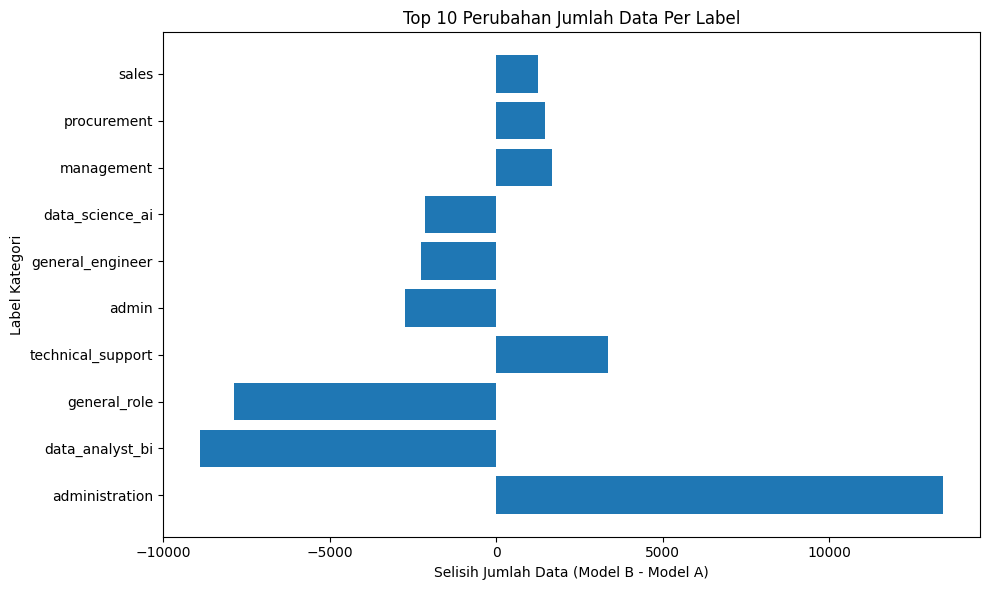

In [29]:
plt.figure(figsize=(10,6))

plt.barh(
    top_changed_labels["category"],
    top_changed_labels["selisih_B_minus_A"]
)

plt.title("Top 10 Perubahan Jumlah Data Per Label")
plt.xlabel("Selisih Jumlah Data (Model B - Model A)")
plt.ylabel("Label Kategori")
plt.tight_layout()
plt.show()

## Kesimpulan A/B Testing

Berdasarkan hasil A/B Testing, Model A dan Model B memiliki perbedaan pada struktur kategori dan distribusi label. Model A masih memiliki label yang bersifat terlalu umum seperti `general` atau `other`, sehingga dapat membuat hasil klasifikasi dan dashboard menjadi kurang spesifik.

Model B memiliki kategori yang lebih bersih karena tidak menggunakan label general atau other. Selain itu, perbandingan per label menunjukkan adanya perubahan distribusi kategori antara Model A dan Model B. Perubahan ini menunjukkan bahwa Model B memiliki mapping kategori yang lebih spesifik dan lebih sesuai untuk kebutuhan dashboard serta proses modelling lanjutan.

Dengan demikian, Model B dipilih sebagai versi yang lebih layak digunakan karena memiliki kategori yang lebih informatif, tidak rancu, dan lebih mudah dianalisis.

## Simpan Hasil A/B Testing

In [30]:
output_path = "/content/drive/MyDrive/data1/ab_testing/hasil_ab_testing_lengkap.csv"
label_output_path = "/content/drive/MyDrive/data1/ab_testing/hasil_perbandingan_per_label.csv"

comparison_ab.to_csv(output_path, index=False)
label_comparison.to_csv(label_output_path, index=False)

print("Hasil A/B Testing berhasil disimpan ke:")
print(output_path)

print("\nHasil perbandingan per label berhasil disimpan ke:")
print(label_output_path)

Hasil A/B Testing berhasil disimpan ke:
/content/drive/MyDrive/data1/ab_testing/hasil_ab_testing_lengkap.csv

Hasil perbandingan per label berhasil disimpan ke:
/content/drive/MyDrive/data1/ab_testing/hasil_perbandingan_per_label.csv
